# Prediccion de GPA

## Configuracion

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyBboxPatch
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

DATA_PATH = Path("data/raw/student_performance.csv")
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)


## Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)
print("Filas, columnas:", df.shape)
df.head()


Filas, columnas: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Datos en crudo

In [3]:
raw_dict = pd.DataFrame([
    ["StudentID", "Identificador del estudiante"],
    ["Age", "Edad del estudiante"],
    ["Gender", "Genero codificado"],
    ["Ethnicity", "Etnia codificada"],
    ["ParentalEducation", "Nivel educativo de los padres codificado"],
    ["StudyTimeWeekly", "Horas de estudio por semana"],
    ["Absences", "Numero de ausencias"],
    ["Tutoring", "Si recibe tutoring"],
    ["ParentalSupport", "Nivel de apoyo parental codificado"],
    ["Extracurricular", "Si participa en actividades extracurriculares"],
    ["Sports", "Si practica deportes"],
    ["Music", "Si participa en musica"],
    ["Volunteering", "Si realiza voluntariado"],
    ["GPA", "Promedio academico"],
    ["GradeClass", "Clase o nivel de rendimiento codificado"],
], columns=["columna", "descripcion"])

raw_summary = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": [df[col].nunique() for col in df.columns],
    "min": [df[col].min() for col in df.columns],
    "max": [df[col].max() for col in df.columns],
    "faltantes": [df[col].isna().sum() for col in df.columns],
})

print("Resumen del dataset crudo")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(raw_dict)
display(raw_summary.round(4))


Resumen del dataset crudo
Filas: 2392 | Columnas: 15


,columna,descripcion
0,StudentID,Identificador del estudiante
1,Age,Edad del estudiante
2,Gender,Genero codificado
3,Ethnicity,Etnia codificada
4,ParentalEducation,Nivel educativo de los padres codificado
5,StudyTimeWeekly,Horas de estudio por semana
6,Absences,Numero de ausencias
7,Tutoring,Si recibe tutoring
8,ParentalSupport,Nivel de apoyo parental codificado
9,Extracurricular,Si participa en actividades extracurriculares


,columna,tipo,valores_unicos,min,max,faltantes
0,StudentID,int64,2392,1001.0000,3392.0000,0
1,Age,int64,4,15.0000,18.0000,0
2,Gender,int64,2,0.0000,1.0000,0
3,Ethnicity,int64,4,0.0000,3.0000,0
4,ParentalEducation,int64,5,0.0000,4.0000,0
5,StudyTimeWeekly,float64,2392,0.0011,19.9781,0
6,Absences,int64,30,0.0000,29.0000,0
7,Tutoring,int64,2,0.0000,1.0000,0
8,ParentalSupport,int64,5,0.0000,4.0000,0
9,Extracurricular,int64,2,0.0000,1.0000,0


## Preparacion de variables

In [4]:
TARGET = "GPA"
DROP_COLUMNS = ["StudentID", "GradeClass"]
CATEGORICAL_FEATURES = [
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
]
NUMERIC_FEATURES = ["Age", "StudyTimeWeekly", "Absences"]


def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_encoder()),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ]
    )


def build_pipeline(model):
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", model),
    ])


def metric_block(y_true, y_pred, prefix):
    mse = mean_squared_error(y_true, y_pred)
    return {
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
        f"{prefix}_rmse": mse ** 0.5,
        f"{prefix}_r2": r2_score(y_true, y_pred),
    }


def cross_validation_block(pipeline, X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        clone(pipeline),
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )
    return {
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean(),
    }


X = df.drop(columns=[TARGET, *DROP_COLUMNS]).copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)


## Entrenamiento y comparacion

In [5]:
models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "svr_rbf": SVR(kernel="rbf", C=10.0, epsilon=0.1),
}

if XGBRegressor is not None:
    models["xgboost"] = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

metrics_records = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    record = {"model": model_name}
    record.update(metric_block(y_train, train_predictions, "train"))
    record.update(metric_block(y_test, test_predictions, "test"))
    record.update(cross_validation_block(pipeline, X, y))

    metrics_records.append(record)
    fitted_pipelines[model_name] = pipeline

metrics_df = pd.DataFrame(metrics_records).sort_values("test_rmse").reset_index(drop=True)
metrics_df.round(4)


,model,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2,cv_mae,cv_rmse,cv_r2
0,linear_regression,0.1591,0.1960,0.9542,0.1551,0.1963,0.9534,0.1592,0.1974,0.9533
1,xgboost,0.1101,0.1381,0.9773,0.1656,0.2117,0.9458,0.1701,0.2138,0.9452
2,svr_rbf,0.0884,0.0974,0.9887,0.2024,0.2520,0.9232,0.2002,0.2491,0.9257
3,random_forest,0.0731,0.0912,0.9901,0.1964,0.2529,0.9226,0.1961,0.2460,0.9275


## Avance actual

In [6]:
best_model_name = metrics_df.loc[0, "model"]
best_row = metrics_df.iloc[0]
best_pipeline = fitted_pipelines[best_model_name]
best_predictions = pd.Series(best_pipeline.predict(X_test), index=y_test.index)

predictions_df = pd.DataFrame({
    "actual_gpa": y_test,
    "predicted_gpa": best_predictions,
})
predictions_df["residual"] = predictions_df["actual_gpa"] - predictions_df["predicted_gpa"]
predictions_df["abs_error"] = predictions_df["residual"].abs()

importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

summary_df = pd.DataFrame([
    {
        "best_model": best_model_name,
        "test_rmse": best_row["test_rmse"],
        "test_r2": best_row["test_r2"],
        "cv_rmse": best_row["cv_rmse"],
        "cv_r2": best_row["cv_r2"],
        "within_0_25": (predictions_df["abs_error"] <= 0.25).mean(),
        "within_0_50": (predictions_df["abs_error"] <= 0.50).mean(),
        "top_features": ", ".join(importance_df.head(5)["feature"].tolist()),
    }
])
summary_df.round(4)


,best_model,test_rmse,test_r2,cv_rmse,cv_r2,within_0_25,within_0_50,top_features
0,linear_regression,0.1963,0.9534,0.1974,0.9533,0.7933,0.9896,"Absences, ParentalSupport, StudyTimeWeekly, Tu..."


## Analisis de XGBoost

In [7]:
if "xgboost" in fitted_pipelines:
    lr_pred = pd.Series(fitted_pipelines["linear_regression"].predict(X_test), index=y_test.index)
    xgb_pred = pd.Series(fitted_pipelines["xgboost"].predict(X_test), index=y_test.index)

    xgb_analysis_df = metrics_df[
        metrics_df["model"].isin(["linear_regression", "xgboost"])
    ][[
        "model",
        "train_rmse",
        "test_rmse",
        "cv_rmse",
        "train_r2",
        "test_r2",
        "cv_r2",
    ]].copy()
    xgb_analysis_df["gap_rmse"] = xgb_analysis_df["test_rmse"] - xgb_analysis_df["train_rmse"]
    xgb_analysis_df["gap_r2"] = xgb_analysis_df["train_r2"] - xgb_analysis_df["test_r2"]

    xgb_similarity_df = pd.DataFrame([
        {
            "mean_abs_diff_lr_vs_xgb": (lr_pred - xgb_pred).abs().mean(),
            "max_abs_diff_lr_vs_xgb": (lr_pred - xgb_pred).abs().max(),
            "prediction_correlation": lr_pred.corr(xgb_pred),
            "share_lr_better": ((y_test - lr_pred).abs() < (y_test - xgb_pred).abs()).mean(),
            "share_xgb_better": ((y_test - xgb_pred).abs() < (y_test - lr_pred).abs()).mean(),
        }
    ])

    display(xgb_analysis_df.round(4))
    display(xgb_similarity_df.round(4))
else:
    print("XGBoost no esta disponible en este entorno.")


,model,train_rmse,test_rmse,cv_rmse,train_r2,test_r2,cv_r2,gap_rmse,gap_r2
0,linear_regression,0.1960,0.1963,0.1974,0.9542,0.9534,0.9533,0.0003,0.0008
1,xgboost,0.1381,0.2117,0.2138,0.9773,0.9458,0.9452,0.0736,0.0315


,mean_abs_diff_lr_vs_xgb,max_abs_diff_lr_vs_xgb,prediction_correlation,share_lr_better,share_xgb_better
0,0.064,0.3191,0.9957,0.5449,0.4551


## Prueba sin Absences

,model,rmse_base,rmse_without_absences,delta_rmse,r2_base,r2_without_absences,delta_r2
0,linear_regression,0.1963,0.8692,0.6729,0.9534,0.0864,-0.8670
1,random_forest,0.2529,0.9278,0.6749,0.9226,-0.0411,-0.9637
3,xgboost,0.2117,0.9398,0.7281,0.9458,-0.0681,-1.0139
2,svr_rbf,0.2520,1.0753,0.8233,0.9232,-0.3984,-1.3216


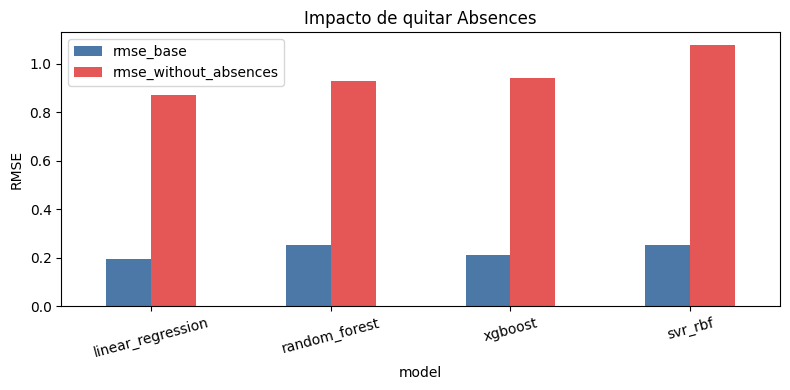

In [8]:
def build_pipeline_without_absences(model):
    numeric_wo_absences = ["Age", "StudyTimeWeekly"]
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_wo_absences,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_encoder()),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ]
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


X_wo_absences = X.drop(columns=["Absences"])
X_train_wo_absences, X_test_wo_absences, y_train_wo_absences, y_test_wo_absences = train_test_split(
    X_wo_absences,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

no_absences_records = []

for model_name, model in models.items():
    base_row = metrics_df.loc[metrics_df["model"] == model_name].iloc[0]
    pipeline_wo_absences = build_pipeline_without_absences(clone(model))
    pipeline_wo_absences.fit(X_train_wo_absences, y_train_wo_absences)
    predictions_wo_absences = pipeline_wo_absences.predict(X_test_wo_absences)
    rmse_wo_absences = mean_squared_error(y_test_wo_absences, predictions_wo_absences) ** 0.5
    r2_wo_absences = r2_score(y_test_wo_absences, predictions_wo_absences)

    no_absences_records.append({
        "model": model_name,
        "rmse_base": base_row["test_rmse"],
        "rmse_without_absences": rmse_wo_absences,
        "delta_rmse": rmse_wo_absences - base_row["test_rmse"],
        "r2_base": base_row["test_r2"],
        "r2_without_absences": r2_wo_absences,
        "delta_r2": r2_wo_absences - base_row["test_r2"],
    })

no_absences_df = pd.DataFrame(no_absences_records).sort_values("rmse_without_absences")
display(no_absences_df.round(4))

ax = no_absences_df.set_index("model")[["rmse_base", "rmse_without_absences"]].plot(
    kind="bar",
    figsize=(8, 4),
    color=["#4C78A8", "#E45756"],
)
ax.set_title("Impacto de quitar Absences")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## Diagrama de flujo

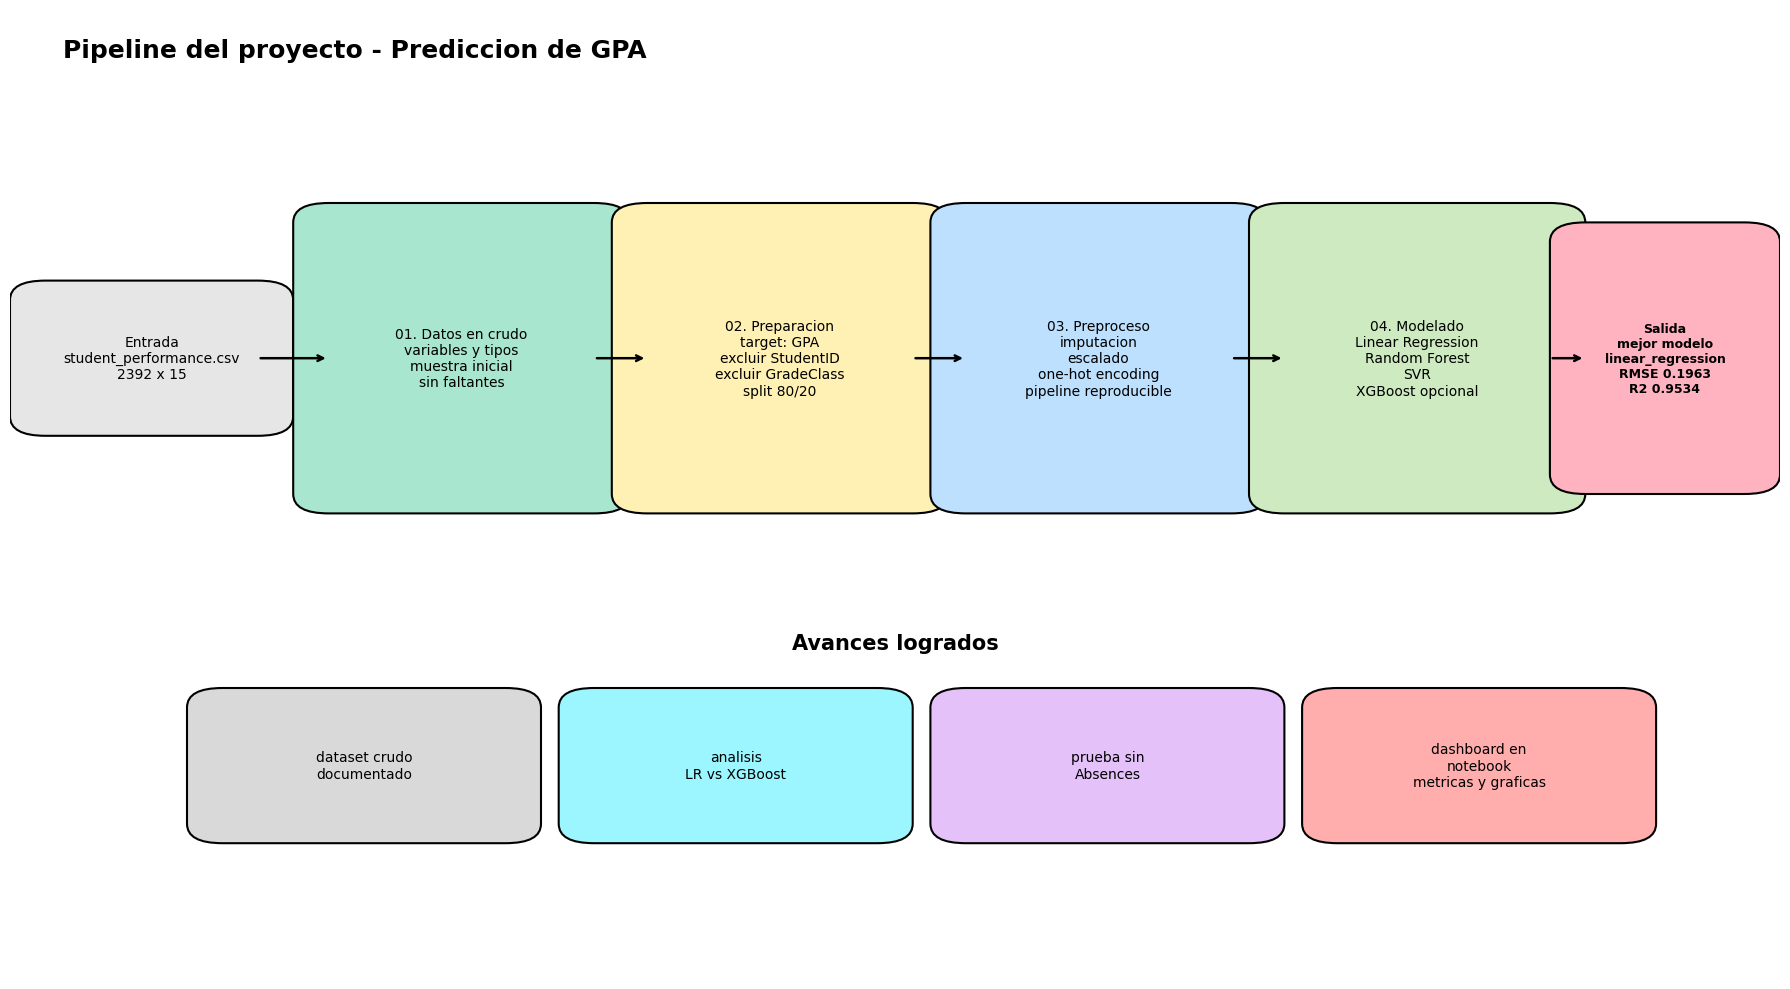

In [9]:
def add_box(ax, x, y, w, h, text, color, size=10, weight="normal"):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=size, weight=weight)


fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.03, 0.95, "Pipeline del proyecto - Prediccion de GPA", fontsize=18, weight="bold")

add_box(ax, 0.02, 0.58, 0.12, 0.12, "Entrada\nstudent_performance.csv\n2392 x 15", "#E6E6E6")
add_box(ax, 0.18, 0.50, 0.15, 0.28, "01. Datos en crudo\nvariables y tipos\nmuestra inicial\nsin faltantes", "#A8E6CF")
add_box(ax, 0.36, 0.50, 0.15, 0.28, "02. Preparacion\ntarget: GPA\nexcluir StudentID\nexcluir GradeClass\nsplit 80/20", "#FFF0B3")
add_box(ax, 0.54, 0.50, 0.15, 0.28, "03. Preproceso\nimputacion\nescalado\none-hot encoding\npipeline reproducible", "#BDE0FE")
add_box(ax, 0.72, 0.50, 0.15, 0.28, "04. Modelado\nLinear Regression\nRandom Forest\nSVR\nXGBoost opcional", "#CDEAC0")
add_box(ax, 0.89, 0.52, 0.09, 0.24, f"Salida\nmejor modelo\n{best_model_name}\nRMSE {best_row['test_rmse']:.4f}\nR2 {best_row['test_r2']:.4f}", "#FFB3C1", size=9, weight="bold")

for start, end in [
    ((0.14, 0.64), (0.18, 0.64)),
    ((0.33, 0.64), (0.36, 0.64)),
    ((0.51, 0.64), (0.54, 0.64)),
    ((0.69, 0.64), (0.72, 0.64)),
    ((0.87, 0.64), (0.89, 0.64)),
]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.8))

ax.text(0.5, 0.34, "Avances logrados", ha="center", fontsize=15, weight="bold")
add_box(ax, 0.12, 0.16, 0.16, 0.12, "dataset crudo\ndocumentado", "#D9D9D9")
add_box(ax, 0.33, 0.16, 0.16, 0.12, "analisis\nLR vs XGBoost", "#9BF6FF")
add_box(ax, 0.54, 0.16, 0.16, 0.12, "prueba sin\nAbsences", "#E4C1F9")
add_box(ax, 0.75, 0.16, 0.16, 0.12, "dashboard en\nnotebook\nmetricas y graficas", "#FFADAD")

plt.tight_layout()
plt.show()


## Importancia de variables

In [10]:
importance_df.head(10).round(4)


,feature,importance_mean,importance_std
5,Absences,1.0056,0.0356
7,ParentalSupport,0.1225,0.0074
4,StudyTimeWeekly,0.1013,0.0058
6,Tutoring,0.0519,0.0041
9,Sports,0.0413,0.0038
8,Extracurricular,0.0400,0.0042
10,Music,0.0119,0.0033
3,ParentalEducation,0.0005,0.0004
1,Gender,0.0004,0.0002
0,Age,0.0001,0.0003


## Graficas

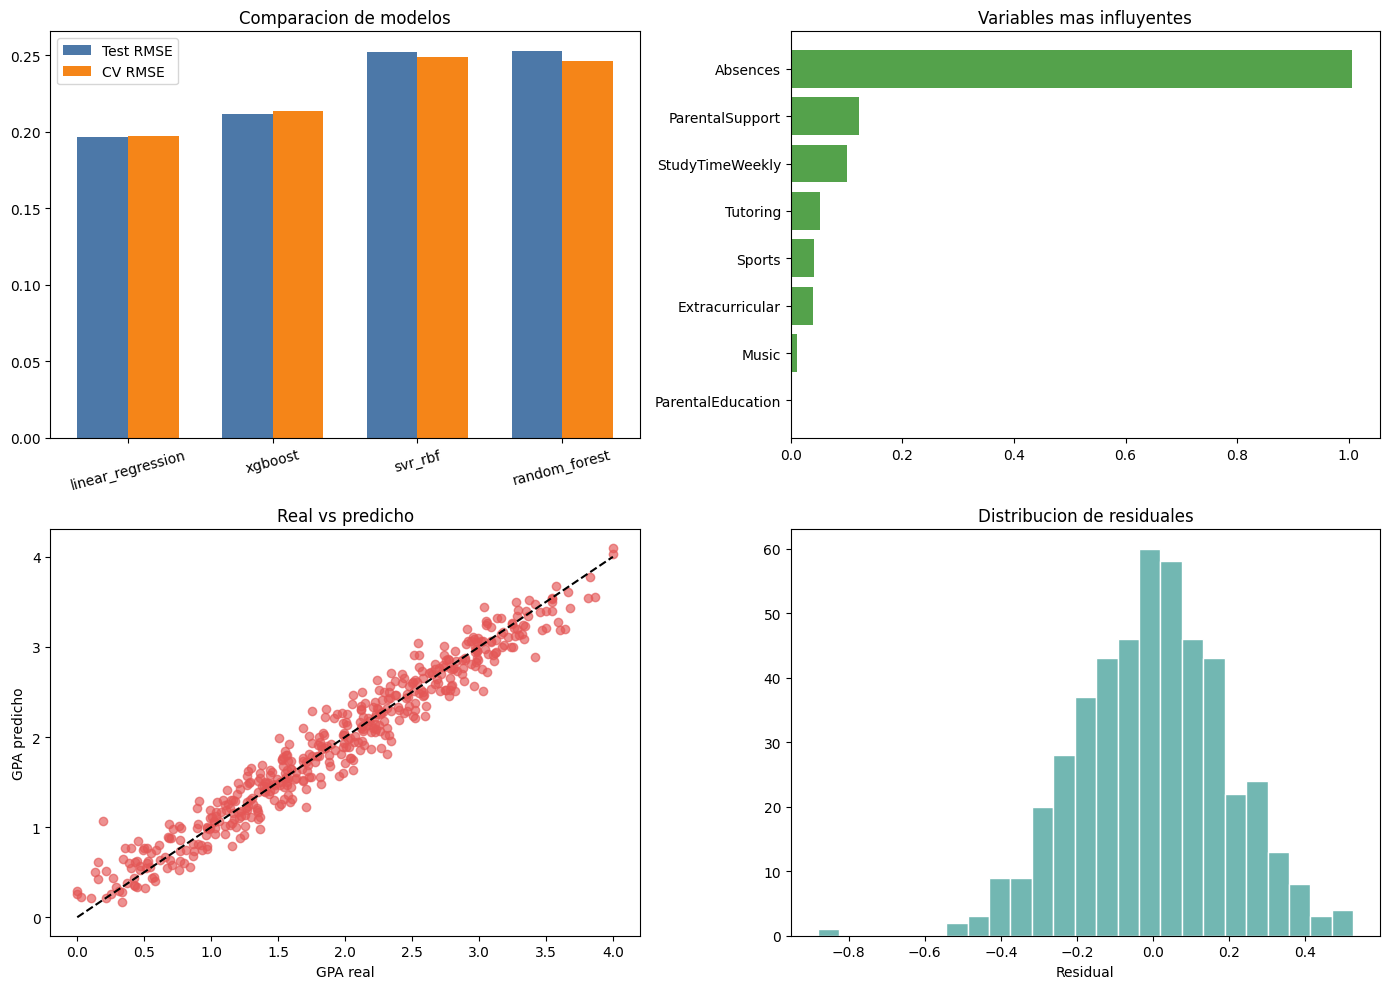

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ordered = metrics_df.sort_values("test_rmse").reset_index(drop=True)
positions = list(range(len(ordered)))
width = 0.35

axes[0, 0].bar([x - width / 2 for x in positions], ordered["test_rmse"], width=width, label="Test RMSE", color="#4C78A8")
axes[0, 0].bar([x + width / 2 for x in positions], ordered["cv_rmse"], width=width, label="CV RMSE", color="#F58518")
axes[0, 0].set_xticks(positions)
axes[0, 0].set_xticklabels(ordered["model"], rotation=15)
axes[0, 0].set_title("Comparacion de modelos")
axes[0, 0].legend()

top_features = importance_df.head(8).sort_values("importance_mean")
axes[0, 1].barh(top_features["feature"], top_features["importance_mean"], color="#54A24B")
axes[0, 1].set_title("Variables mas influyentes")

axes[1, 0].scatter(y_test, best_predictions, alpha=0.65, color="#E45756")
axes[1, 0].plot([0, 4], [0, 4], linestyle="--", color="black")
axes[1, 0].set_xlabel("GPA real")
axes[1, 0].set_ylabel("GPA predicho")
axes[1, 0].set_title("Real vs predicho")

axes[1, 1].hist(predictions_df["residual"], bins=25, color="#72B7B2", edgecolor="white")
axes[1, 1].set_title("Distribucion de residuales")
axes[1, 1].set_xlabel("Residual")

plt.tight_layout()
plt.show()


## Simulacion de intervencion

,escenario,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,GPA_estimado
0,actual,6.3863,27.0,0.0,1.0,0.1745
1,intervenido,11.3863,17.0,1.0,2.0,1.7158


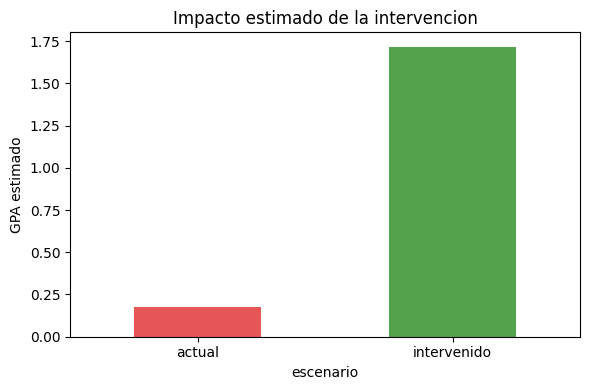

In [12]:
intervention_case = X_test.copy()
intervention_case["predicted_gpa"] = best_predictions
intervention_case = intervention_case.sort_values(
    ["predicted_gpa", "Absences", "StudyTimeWeekly"],
    ascending=[True, False, True],
)

current_case = intervention_case.iloc[0].drop(labels=["predicted_gpa"]).copy()
improved_case = current_case.copy()
improved_case["Absences"] = max(0, int(current_case["Absences"]) - 10)
improved_case["StudyTimeWeekly"] = min(20, float(current_case["StudyTimeWeekly"]) + 5)
improved_case["Tutoring"] = 1
improved_case["ParentalSupport"] = min(4, int(current_case["ParentalSupport"]) + 1)

current_pred = float(best_pipeline.predict(pd.DataFrame([current_case]))[0])
improved_pred = float(best_pipeline.predict(pd.DataFrame([improved_case]))[0])

intervention_df = pd.DataFrame([
    {
        "escenario": "actual",
        "StudyTimeWeekly": current_case["StudyTimeWeekly"],
        "Absences": current_case["Absences"],
        "Tutoring": current_case["Tutoring"],
        "ParentalSupport": current_case["ParentalSupport"],
        "GPA_estimado": current_pred,
    },
    {
        "escenario": "intervenido",
        "StudyTimeWeekly": improved_case["StudyTimeWeekly"],
        "Absences": improved_case["Absences"],
        "Tutoring": improved_case["Tutoring"],
        "ParentalSupport": improved_case["ParentalSupport"],
        "GPA_estimado": improved_pred,
    },
])

display(intervention_df.round(4))

ax = intervention_df.plot(
    x="escenario",
    y="GPA_estimado",
    kind="bar",
    figsize=(6, 4),
    legend=False,
    color=["#E45756", "#54A24B"],
)
ax.set_title("Impacto estimado de la intervencion")
ax.set_ylabel("GPA estimado")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Motor de recomendaciones para estudiante

In [13]:
from itertools import product

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

GOOD_PERFORMANCE_THRESHOLD = 2.5
GOOD_PERFORMANCE_LABEL = f"GPA >= {GOOD_PERFORMANCE_THRESHOLD}"

# Motor de ayuda: quitamos variables sensibles y no accionables para recomendaciones p?blicas.
ADVICE_NUMERIC_FEATURES = ["Age", "StudyTimeWeekly", "Absences"]
ADVICE_CATEGORICAL_FEATURES = [
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
]
ADVICE_FEATURES = ADVICE_NUMERIC_FEATURES + ADVICE_CATEGORICAL_FEATURES
ACTIONABLE_FEATURES = [
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering",
]
EXCLUDED_FROM_ADVICE = ["StudentID", "GradeClass", "Gender", "Ethnicity"]


def build_advice_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                ADVICE_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_encoder()),
                ]),
                ADVICE_CATEGORICAL_FEATURES,
            ),
        ]
    )


def build_advice_pipeline(model):
    return Pipeline([
        ("preprocessor", build_advice_preprocessor()),
        ("model", model),
    ])


X_advice = df[ADVICE_FEATURES].copy()
y_good = (df[TARGET] >= GOOD_PERFORMANCE_THRESHOLD).astype(int)

X_train_advice, X_test_advice, y_train_good, y_test_good = train_test_split(
    X_advice,
    y_good,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_good,
)

classifier_candidates = {
    "logistic_regression": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "random_forest_classifier": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "hist_gradient_boosting_classifier": HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=350,
        max_leaf_nodes=15,
        l2_regularization=0.5,
        random_state=RANDOM_STATE,
    ),
}

if XGBClassifier is not None:
    classifier_candidates["xgboost_classifier"] = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=2.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )

classifier_records = []
fitted_classifiers = {}
cv_classifier = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in classifier_candidates.items():
    pipeline = build_advice_pipeline(model)
    pipeline.fit(X_train_advice, y_train_good)
    probabilities = pipeline.predict_proba(X_test_advice)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    cv_scores = cross_validate(
        pipeline,
        X_advice,
        y_good,
        cv=cv_classifier,
        scoring={
            "roc_auc": "roc_auc",
            "average_precision": "average_precision",
            "f1": "f1",
            "accuracy": "accuracy",
        },
        n_jobs=-1,
    )

    classifier_records.append({
        "model": model_name,
        "test_roc_auc": roc_auc_score(y_test_good, probabilities),
        "test_avg_precision": average_precision_score(y_test_good, probabilities),
        "test_accuracy": accuracy_score(y_test_good, predictions),
        "test_precision": precision_score(y_test_good, predictions, zero_division=0),
        "test_recall": recall_score(y_test_good, predictions, zero_division=0),
        "test_f1": f1_score(y_test_good, predictions, zero_division=0),
        "test_brier": brier_score_loss(y_test_good, probabilities),
        "cv_roc_auc": cv_scores["test_roc_auc"].mean(),
        "cv_avg_precision": cv_scores["test_average_precision"].mean(),
        "cv_f1": cv_scores["test_f1"].mean(),
        "cv_accuracy": cv_scores["test_accuracy"].mean(),
    })
    fitted_classifiers[model_name] = pipeline

classifier_metrics_df = pd.DataFrame(classifier_records).sort_values(
    ["cv_roc_auc", "test_brier"],
    ascending=[False, True],
).reset_index(drop=True)

best_classifier_name = classifier_metrics_df.loc[0, "model"]
best_base_classifier = classifier_candidates[best_classifier_name]

# Calibramos el mejor clasificador para que la probabilidad sea m?s ?til como mensaje al estudiante.
best_classifier_pipeline = CalibratedClassifierCV(
    estimator=build_advice_pipeline(best_base_classifier),
    method="sigmoid",
    cv=5,
)
best_classifier_pipeline.fit(X_train_advice, y_train_good)

calibrated_probabilities = best_classifier_pipeline.predict_proba(X_test_advice)[:, 1]
calibrated_predictions = (calibrated_probabilities >= 0.5).astype(int)
calibrated_metrics_df = pd.DataFrame([
    {
        "model": f"{best_classifier_name}_calibrated",
        "test_roc_auc": roc_auc_score(y_test_good, calibrated_probabilities),
        "test_avg_precision": average_precision_score(y_test_good, calibrated_probabilities),
        "test_accuracy": accuracy_score(y_test_good, calibrated_predictions),
        "test_precision": precision_score(y_test_good, calibrated_predictions, zero_division=0),
        "test_recall": recall_score(y_test_good, calibrated_predictions, zero_division=0),
        "test_f1": f1_score(y_test_good, calibrated_predictions, zero_division=0),
        "test_brier": brier_score_loss(y_test_good, calibrated_probabilities),
    }
])

# Regresor de apoyo para estimar GPA usando las mismas variables responsables del motor de ayuda.
advice_regressor = build_advice_pipeline(LinearRegression())
advice_regressor.fit(X_train_advice, y.loc[X_train_advice.index])


def predict_advice_gpa(case):
    return float(advice_regressor.predict(pd.DataFrame([case[ADVICE_FEATURES]]))[0])


def predict_good_performance_probability(case):
    return float(best_classifier_pipeline.predict_proba(pd.DataFrame([case[ADVICE_FEATURES]]))[0, 1])


def performance_level_from_probability(probability):
    if probability >= 0.75:
        return "alta probabilidad de buen rendimiento"
    if probability >= 0.50:
        return "probabilidad media de buen rendimiento"
    if probability >= 0.25:
        return "riesgo moderado"
    return "riesgo alto"


def build_intervention_options(case):
    absence_options = [("mantener ausencias", 0, lambda x: None)]
    for reduction in [5, 10, 15]:
        if case["Absences"] >= reduction:
            absence_options.append((
                f"reducir ausencias en {reduction}",
                reduction,
                lambda x, r=reduction: x.__setitem__("Absences", max(0, int(x["Absences"]) - r)),
            ))

    study_options = [("mantener horas de estudio", 0, lambda x: None)]
    for increase in [3, 5, 8]:
        if case["StudyTimeWeekly"] + increase <= 20:
            study_options.append((
                f"aumentar estudio en {increase}h/semana",
                increase,
                lambda x, h=increase: x.__setitem__("StudyTimeWeekly", min(20, float(x["StudyTimeWeekly"]) + h)),
            ))

    tutoring_options = [("mantener tutoring", 0, lambda x: None)]
    if case["Tutoring"] == 0:
        tutoring_options.append(("activar tutoring", 1, lambda x: x.__setitem__("Tutoring", 1)))

    support_options = [("mantener apoyo parental", 0, lambda x: None)]
    for increase in [1, 2]:
        if case["ParentalSupport"] + increase <= 4:
            support_options.append((
                f"subir apoyo parental en {increase}",
                increase,
                lambda x, h=increase: x.__setitem__("ParentalSupport", min(4, int(x["ParentalSupport"]) + h)),
            ))

    activity_columns = ["Extracurricular", "Sports", "Music", "Volunteering"]
    activity_options = [("sin actividad nueva", 0, lambda x: None)]
    for column in activity_columns:
        if case[column] == 0:
            activity_options.append((
                f"activar {column}",
                1,
                lambda x, col=column: x.__setitem__(col, 1),
            ))

    return absence_options, study_options, tutoring_options, support_options, activity_options


def generate_intervention_plans(case, top_n=8):
    current_gpa = predict_advice_gpa(case)
    current_probability = predict_good_performance_probability(case)
    options = build_intervention_options(case)
    rows = []

    for selected_options in product(*options):
        labels = [item[0] for item in selected_options if not item[0].startswith("mantener") and item[0] != "sin actividad nueva"]
        if not labels:
            continue

        proposed_case = case.copy()
        effort_score = 0
        for _, effort, transform in selected_options:
            effort_score += effort
            transform(proposed_case)

        proposed_gpa = predict_advice_gpa(proposed_case)
        proposed_probability = predict_good_performance_probability(proposed_case)
        delta_gpa = proposed_gpa - current_gpa
        delta_probability = proposed_probability - current_probability

        if delta_gpa <= 0 and delta_probability <= 0:
            continue

        rows.append({
            "plan": " + ".join(labels),
            "gpa_actual": current_gpa,
            "gpa_estimado": proposed_gpa,
            "delta_gpa": delta_gpa,
            "prob_actual": current_probability,
            "prob_estimada": proposed_probability,
            "delta_prob": delta_probability,
            "esfuerzo": effort_score,
            "Absences_plan": proposed_case["Absences"],
            "StudyTimeWeekly_plan": proposed_case["StudyTimeWeekly"],
            "Tutoring_plan": proposed_case["Tutoring"],
            "ParentalSupport_plan": proposed_case["ParentalSupport"],
        })

    plan_df = pd.DataFrame(rows)
    if plan_df.empty:
        return plan_df, []

    plan_df = plan_df.sort_values(
        ["delta_prob", "delta_gpa", "esfuerzo"],
        ascending=[False, False, True],
    ).drop_duplicates(subset=["Absences_plan", "StudyTimeWeekly_plan", "Tutoring_plan", "ParentalSupport_plan"]).head(top_n).reset_index(drop=True)

    best_plan = plan_df.iloc[0]
    messages = [
        f"Estado actual: GPA estimado {current_gpa:.2f}; probabilidad real del clasificador para {GOOD_PERFORMANCE_LABEL}: {current_probability:.1%}; nivel: {performance_level_from_probability(current_probability)}.",
        f"Mejor plan recomendado: {best_plan['plan']}.",
        f"Impacto esperado: GPA {current_gpa:.2f} -> {best_plan['gpa_estimado']:.2f} (+{best_plan['delta_gpa']:.2f}); probabilidad {current_probability:.1%} -> {best_plan['prob_estimada']:.1%} (+{best_plan['delta_prob'] * 100:.1f} puntos porcentuales).",
        "Prioridad practica: atacar primero ausencias y despues reforzar estudio/tutoring, porque son las variables accionables con mayor impacto simulado.",
        f"Variables excluidas de recomendacion: {', '.join(EXCLUDED_FROM_ADVICE)}. No se pide ni se recomienda cambiar variables sensibles o no accionables.",
        "Nota tecnica: la recomendacion es una simulacion basada en modelos entrenados con este dataset; debe validarse con datos reales de la escuela antes de usarse para decisiones formales.",
    ]

    return plan_df, messages


# Caso de demostracion: estudiante con riesgo alto identificado en la simulacion previa.
student_case = current_case[ADVICE_FEATURES].copy()
student_plan_df, student_messages = generate_intervention_plans(student_case)

print("Metrica del clasificador de buen rendimiento")
display(classifier_metrics_df.round(4))
display(calibrated_metrics_df.round(4))

print("Planes recomendados para el estudiante")
display(student_plan_df.round(4))

print("Mensajes que imprime el sistema:\n")
for message in student_messages:
    print("- " + message)


Metrica del clasificador de buen rendimiento


,model,test_roc_auc,test_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_brier,cv_roc_auc,cv_avg_precision,cv_f1,cv_accuracy
0,logistic_regression,0.9871,0.9707,0.9311,0.8418,0.9433,0.8896,0.0477,0.9876,0.9724,0.8947,0.9335
1,xgboost_classifier,0.9871,0.9715,0.9478,0.9143,0.9078,0.9110,0.0419,0.9867,0.9710,0.9013,0.9419
2,hist_gradient_boosting_classifier,0.9854,0.9669,0.9332,0.8658,0.9149,0.8897,0.0480,0.9830,0.9622,0.8880,0.9339
3,random_forest_classifier,0.9793,0.9519,0.8998,0.7627,0.9574,0.8491,0.0845,0.9793,0.9534,0.8555,0.9076


,model,test_roc_auc,test_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_brier
0,logistic_regression_calibrated,0.9871,0.9704,0.9478,0.9143,0.9078,0.911,0.0412


Planes recomendados para el estudiante


,plan,gpa_actual,gpa_estimado,delta_gpa,prob_actual,prob_estimada,delta_prob,esfuerzo,Absences_plan,StudyTimeWeekly_plan,Tutoring_plan,ParentalSupport_plan
0,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.6387,2.4779,0.0,0.7889,0.7889,27,12.0,14.3863,1.0,3.0
1,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.5524,2.3916,0.0,0.6705,0.6705,24,12.0,11.3863,1.0,3.0
2,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.4840,2.3233,0.0,0.5750,0.5750,26,12.0,14.3863,1.0,2.0
3,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.4948,2.3341,0.0,0.5747,0.5747,22,12.0,9.3863,1.0,3.0
4,reducir ausencias en 15 + activar tutoring + s...,0.1607,2.4086,2.2478,0.0,0.4212,0.4212,19,12.0,6.3863,1.0,3.0
5,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.3978,2.2370,0.0,0.4206,0.4206,23,12.0,11.3863,1.0,2.0
6,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.3815,2.2207,0.0,0.3633,0.3633,26,12.0,14.3863,0.0,3.0
7,reducir ausencias en 15 + aumentar estudio en ...,0.1607,2.3429,2.1822,0.0,0.3374,0.3374,25,12.0,14.3863,1.0,1.0


Mensajes que imprime el sistema:

- Estado actual: GPA estimado 0.16; probabilidad real del clasificador para GPA >= 2.5: 0.0%; nivel: riesgo alto.
- Mejor plan recomendado: reducir ausencias en 15 + aumentar estudio en 8h/semana + activar tutoring + subir apoyo parental en 2 + activar Extracurricular.
- Impacto esperado: GPA 0.16 -> 2.64 (+2.48); probabilidad 0.0% -> 78.9% (+78.9 puntos porcentuales).
- Prioridad practica: atacar primero ausencias y despues reforzar estudio/tutoring, porque son las variables accionables con mayor impacto simulado.
- Variables excluidas de recomendacion: StudentID, GradeClass, Gender, Ethnicity. No se pide ni se recomienda cambiar variables sensibles o no accionables.
- Nota tecnica: la recomendacion es una simulacion basada en modelos entrenados con este dataset; debe validarse con datos reales de la escuela antes de usarse para decisiones formales.


## Documentacion de mensajes

In [14]:
message_documentation = pd.DataFrame([
    {
        "tipo_mensaje": "Estado actual",
        "cuando_aparece": "Siempre, al evaluar un estudiante.",
        "que_comunica": "GPA estimado por regresor, probabilidad real del clasificador y nivel de riesgo.",
        "base_tecnica": "Regresor de GPA + clasificador calibrado para GPA >= 2.5.",
    },
    {
        "tipo_mensaje": "Mejor plan recomendado",
        "cuando_aparece": "Despues de generar y ordenar planes de intervencion.",
        "que_comunica": "Combinacion de acciones con mayor mejora estimada en probabilidad y GPA.",
        "base_tecnica": "Busqueda combinatoria sobre acciones factibles: ausencias, estudio, tutoring, apoyo parental y actividades.",
    },
    {
        "tipo_mensaje": "Impacto esperado",
        "cuando_aparece": "Para el plan ganador y en la tabla de planes.",
        "que_comunica": "Cambio estimado de GPA y cambio en puntos porcentuales de probabilidad de buen rendimiento.",
        "base_tecnica": "Comparacion entre prediccion actual y prediccion del caso simulado.",
    },
    {
        "tipo_mensaje": "Prioridad practica",
        "cuando_aparece": "Cuando el sistema resume como actuar.",
        "que_comunica": "Orden sugerido de accion para el estudiante o tutor.",
        "base_tecnica": "Ranking por delta_prob, delta_gpa y esfuerzo estimado.",
    },
    {
        "tipo_mensaje": "Variables excluidas",
        "cuando_aparece": "Siempre, como control etico.",
        "que_comunica": "Aclara que Gender, Ethnicity, StudentID y GradeClass no se usan para recomendar acciones.",
        "base_tecnica": "Separacion entre variables predictivas historicas y variables permitidas para recomendacion accionable.",
    },
    {
        "tipo_mensaje": "Nota tecnica",
        "cuando_aparece": "Siempre, al final de la recomendacion.",
        "que_comunica": "La recomendacion es simulada y debe validarse con datos reales de la escuela.",
        "base_tecnica": "Prevencion de uso como decision automatica sin supervision humana.",
    },
])

display(message_documentation)


,tipo_mensaje,cuando_aparece,que_comunica,base_tecnica
0,Estado actual,"Siempre, al evaluar un estudiante.","GPA estimado por regresor, probabilidad real d...",Regresor de GPA + clasificador calibrado para ...
1,Mejor plan recomendado,Despues de generar y ordenar planes de interve...,Combinacion de acciones con mayor mejora estim...,Busqueda combinatoria sobre acciones factibles...
2,Impacto esperado,Para el plan ganador y en la tabla de planes.,Cambio estimado de GPA y cambio en puntos porc...,Comparacion entre prediccion actual y predicci...
3,Prioridad practica,Cuando el sistema resume como actuar.,Orden sugerido de accion para el estudiante o ...,"Ranking por delta_prob, delta_gpa y esfuerzo e..."
4,Variables excluidas,"Siempre, como control etico.","Aclara que Gender, Ethnicity, StudentID y Grad...",Separacion entre variables predictivas histori...
5,Nota tecnica,"Siempre, al final de la recomendacion.",La recomendacion es simulada y debe validarse ...,Prevencion de uso como decision automatica sin...


## Figuras y tablas para el paper

Genera los archivos finales usados por el articulo en `paper/figures/` y `paper/tables/`.


In [15]:
import runpy
from pathlib import Path

runpy.run_path("paper/generate_paper_assets.py", run_name="__main__")

print("Figuras generadas:")
for path in sorted(Path("paper/figures").glob("*.png")):
    print("-", path.as_posix())

print("\nTablas generadas:")
for path in sorted(Path("paper/tables").glob("*.csv")):
    print("-", path.as_posix())


{
  "dataset": {
    "rows": 2392,
    "columns": 15,
    "missing_total": 0,
    "gpa_min": 0.0,
    "gpa_max": 4.0,
    "gpa_mean": 1.9061863027265407,
    "good_performance_threshold": 2.5,
    "good_performance_count": 706,
    "low_performance_count": 1686,
    "absences_gpa_corr": -0.9193135764208641
  },
  "best_regression_model": "linear_regression",
  "best_regression_metrics": {
    "train_mae": 0.15910503696480374,
    "train_rmse": 0.19601328967561646,
    "train_r2": 0.9542382758666188,
    "test_mae": 0.1550560560078522,
    "test_rmse": 0.19630825342373784,
    "test_r2": 0.9533977379675411,
    "cv_mae": 0.15920923252183522,
    "cv_rmse": 0.1974019290666496,
    "cv_r2": 0.9532733721820877
  },
  "top_features": [
    {
      "feature": "Absences",
      "importance_mean": 1.0055982937604124,
      "importance_std": 0.03555225176131059
    },
    {
      "feature": "ParentalSupport",
      "importance_mean": 0.12247280971180707,
      "importance_std": 0.00738341644458

## Conclusiones finales

In [16]:
conclusions = [
    f"El mejor modelo de regresion final es {best_model_name}, con test RMSE de {best_row['test_rmse']:.4f} y test R2 de {best_row['test_r2']:.4f}.",
    "XGBoost genera predicciones muy parecidas a LinearRegression, pero muestra mayor sobreajuste entre train y test.",
    f"Al quitar Absences, el RMSE del mejor modelo pasa de {no_absences_df.loc[no_absences_df['model'] == 'linear_regression', 'rmse_base'].iloc[0]:.4f} a {no_absences_df.loc[no_absences_df['model'] == 'linear_regression', 'rmse_without_absences'].iloc[0]:.4f}, confirmando que es la variable mas critica.",
    f"El clasificador de buen rendimiento usa el umbral {GOOD_PERFORMANCE_LABEL} y entrega probabilidades para comparar escenarios de intervencion.",
    "El motor de recomendaciones genera planes accionables, simula su impacto y prioriza los que mas aumentan GPA y probabilidad de buen rendimiento.",
    "La utilidad practica del proyecto esta en detectar riesgo academico temprano, explicar factores de riesgo y sugerir intervenciones supervisadas por tutores o escuela.",
]

for i, conclusion in enumerate(conclusions, start=1):
    print(f"{i}. {conclusion}")


1. El mejor modelo de regresion final es linear_regression, con test RMSE de 0.1963 y test R2 de 0.9534.
2. XGBoost genera predicciones muy parecidas a LinearRegression, pero muestra mayor sobreajuste entre train y test.
3. Al quitar Absences, el RMSE del mejor modelo pasa de 0.1963 a 0.8692, confirmando que es la variable mas critica.
4. El clasificador de buen rendimiento usa el umbral GPA >= 2.5 y entrega probabilidades para comparar escenarios de intervencion.
5. El motor de recomendaciones genera planes accionables, simula su impacto y prioriza los que mas aumentan GPA y probabilidad de buen rendimiento.
6. La utilidad practica del proyecto esta en detectar riesgo academico temprano, explicar factores de riesgo y sugerir intervenciones supervisadas por tutores o escuela.
